In this notebook we have performed general image processing techniques on the extracted faces.

Histogram Equalization is performed to balance the intensity values; followed by computaion of the 2D Discrete Fourier Spectrum of the image, in order to analyze the frequency distribution. For face extraction, we used Haar Cascades and OpenCV open source library.

In [1]:
import os
for root, folders, filenames in os.walk('/kaggle/input'):
    print(root, folders)
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline
import cv2
plt.style.use('ggplot')

/kaggle/input ['haar-cascades-for-face-detection', 'deepfake-detection-challenge']
/kaggle/input/haar-cascades-for-face-detection []
/kaggle/input/deepfake-detection-challenge ['train_sample_videos', 'test_videos']
/kaggle/input/deepfake-detection-challenge/train_sample_videos []
/kaggle/input/deepfake-detection-challenge/test_videos []


In [2]:
count = 0
extensions = []
file_name = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        count += 1
        file_ext , f = [filename.split(".")[-1], filename]
        extensions.append(file_ext)
        file_name.append(f)

extensions_set = set(extensions)
print("Extensions present \n", extensions_set)

Extensions present 
 {'mp4', 'xml', 'json', 'csv'}


In [3]:
print("json present = ", extensions.count('json'))
print("mp4 present = ", extensions.count('mp4'))
print("csv present = ", extensions.count('csv'))


json present =  1
mp4 present =  800
csv present =  1


In [4]:
extensions.index('json')

146

In [5]:
file_name[136]

'cyxlcuyznd.mp4'

In [6]:
# studying the metadata file
metadata_file_df = pd.DataFrame(pd.read_json('/kaggle/input/deepfake-detection-challenge/train_sample_videos/metadata.json').T)
metadata_file_df.head()

,label,split,original
aagfhgtpmv.mp4,FAKE,train,vudstovrck.mp4
aapnvogymq.mp4,FAKE,train,jdubbvfswz.mp4
abarnvbtwb.mp4,REAL,train,None
abofeumbvv.mp4,FAKE,train,atvmxvwyns.mp4
abqwwspghj.mp4,FAKE,train,qzimuostzz.mp4


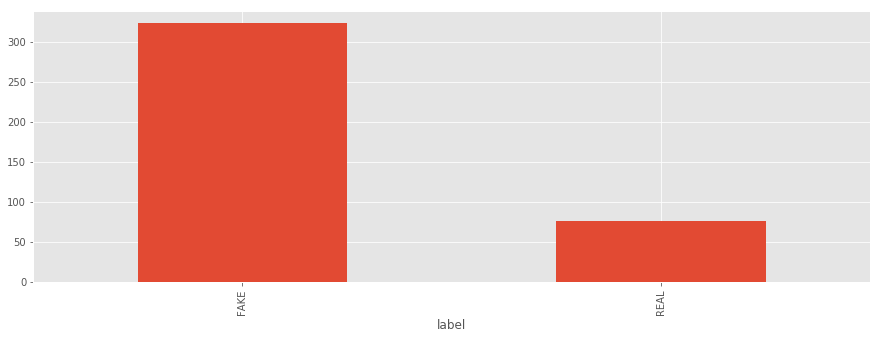

In [7]:
stats = metadata_file_df.groupby('label').size()
stats.plot(figsize = (15,5), kind = 'bar', label = 'Information extracted from JSON Metadata file')

In [8]:
train_dir = '/kaggle/input/deepfake-detection-challenge/train_sample_videos/'
# preparing a list of training videos
train_video_files = [train_dir + i for i in os.listdir(train_dir)]
train_video_files

['/kaggle/input/deepfake-detection-challenge/train_sample_videos/dkzvdrzcnr.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/acqfdwsrhi.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/dzqwgqewhu.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/duycddgtrl.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/akzbnazxtz.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/ccfoszqabv.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/eprybmbpba.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/chtapglbcj.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/acifjvzvpm.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/dbtbbhakdv.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/bydaidkpdp.mp4',
 '/kaggle/input/deepfake-detection-challenge/train_sample_videos/dcamvmuors.mp4',
 '/kaggle/input/

**Histogram equalization** is a non-linear process. Channel splitting and equalizing each channel separately is not the proper way for equalization of contrast. Equalization involves Intensity values of the image not the color components. So for a simple RGB color image, HE should not be applied individually on each channel. Rather, it should be applied such that intensity values are equalized without disturbing the color balance of the image. So, the first step is to convert the color space of the image from RGB into one of the color spaces which separate intensity values from color components. Some of these are:

HSV/HLS


YUV


YCbCr


Convert the image from RGB to one of the above mentioned color spaces. YCbCr is preferred as it is designed for digital images. Perform HE of the intensity plane Y. Convert the image back to RGB.

In [9]:
face_cascade = cv2.CascadeClassifier('/kaggle/input/haar-cascades-for-face-detection/haarcascade_frontalface_default.xml')
def detect(gray, frame):
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    facelist = []
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2) 
        roi_gray = gray[y:y+h, x:x+w] # zone of interest
        roi_color = frame[y:y+h, x:x+w]# zone of interest 
        facelist.append(frame[y:y+h, x:x+w])
    return facelist

def histogram_equalization(image):
    image_YCbCr = cv2.cvtColor(image,cv2.COLOR_BGR2YCrCb)
    image_YCbCr[:,:,0] = cv2.equalizeHist(image_YCbCr[:,:,0]) 
    image = cv2.cvtColor(image_YCbCr, cv2.COLOR_YCrCb2BGR)
    return(image)

def gray_img(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


**Fourier Transform** is used to analyze the frequency characteristics of various filters. For images, 2D Discrete Fourier Transform (DFT) is used to find the frequency domain. A fast algorithm called Fast Fourier Transform (FFT) is used for calculation of DFT. 


OpenCV provides the functions cv2.dft() and cv2.idft() for this. It returns the same result as previous, but with two channels. First channel will have the real part of the result and second channel will have the imaginary part of the result. The input image should be converted to np.float32 first.



In [10]:
def freq_analysis(image):
    dft = cv2.dft(np.float32(image),flags = cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))
    return magnitude_spectrum

(-0.5, 1919.5, 1079.5, -0.5)

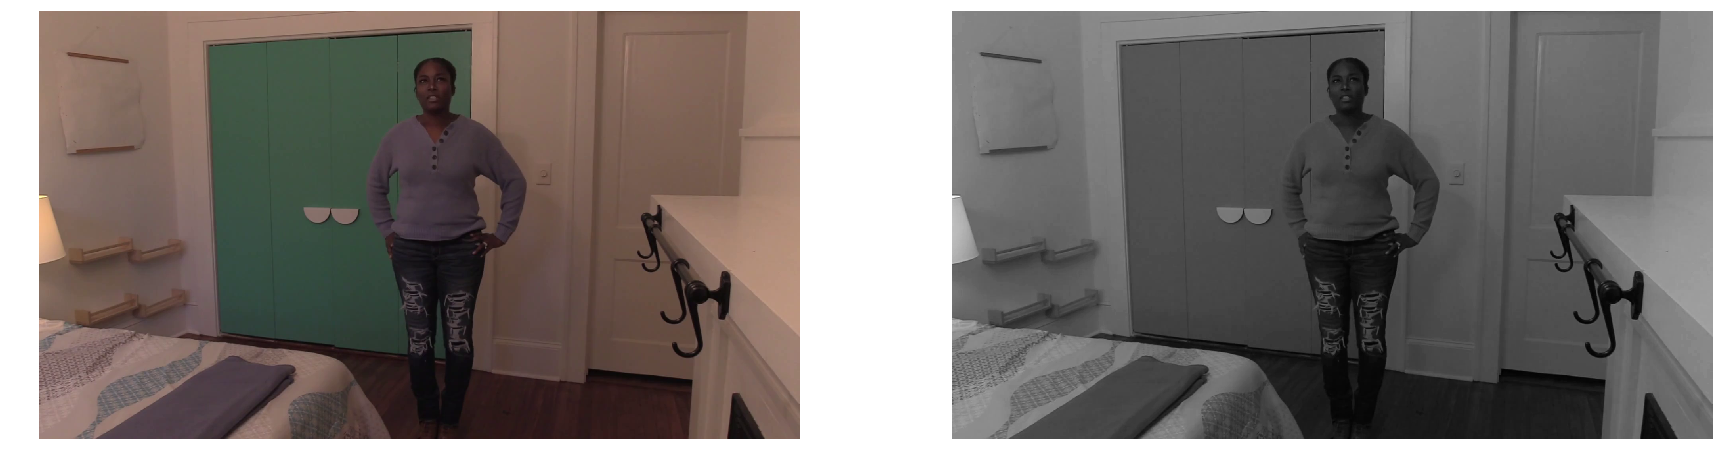

In [11]:
v_cap = cv2.VideoCapture(train_video_files[72]) 
_, frame = v_cap.read()
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
f, (ax1, ax2) = plt.subplots(1, 2, figsize = (30,22))
ax1.imshow(frame, cmap = 'gray')
ax2.imshow(gray, cmap = 'gray')
ax1.axis('off')
ax2.axis('off')

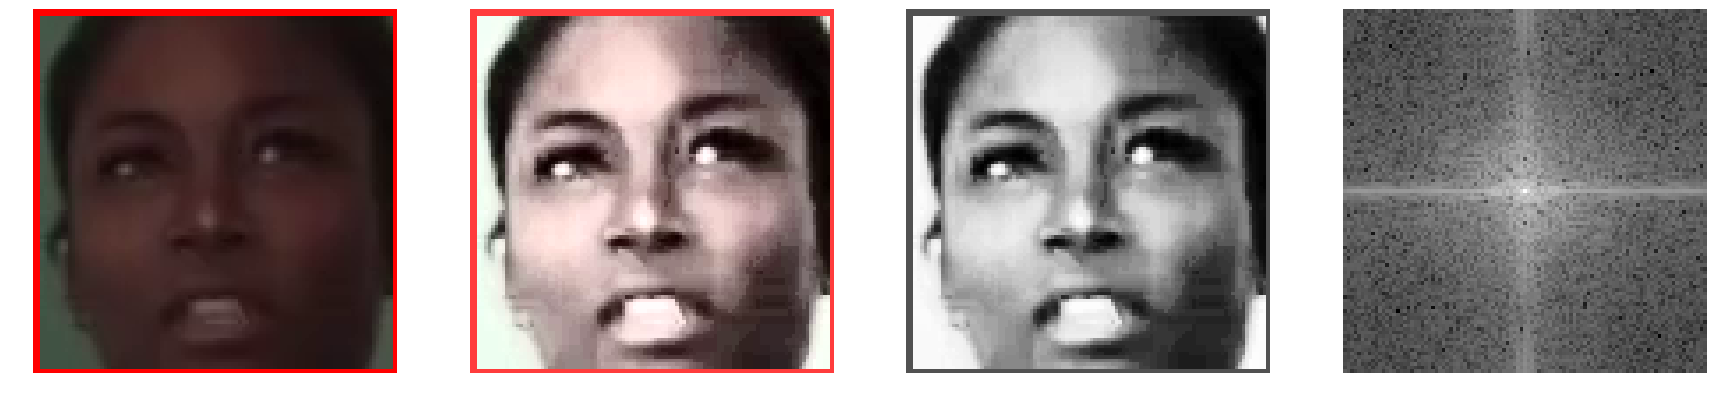

In [12]:
facelist = detect(gray, frame)
plt.figsize = (22,8)
for face in facelist:
    f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize = (30,22))
    face_he = histogram_equalization(face)
    gray = gray_img(face_he)
    magnitude_spectrum = freq_analysis(gray)
    ax1.imshow(face, cmap = 'gray')
    ax2.imshow(face_he, cmap = 'gray')
    ax3.imshow(gray_img(face_he), cmap = 'gray')
    ax4.imshow(magnitude_spectrum, cmap = 'gray')
    ax1.axis('off')
    ax2.axis('off')
    ax3.axis('off')
    ax4.axis('off')
    plt.show()